## Análisis de datos II - Clase 4
---

### Detección de anomalías con KNN y Local Outlier Factor (LOF)

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

In [109]:
# El archivo no trae encabezados,los definimos según wine.names
columnas = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue',
    'od280_od315', 'proline'
]

df = pd.read_csv('../datasets/wine.data', header=None, names=columnas)
df.head()

,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
# Opción: usar todas las variables numéricas (excluimos 'class', que es la etiqueta)
# features = [c for c in df.columns if c != 'class']

# Usar solo 2 variables para simplificar el ejemplo
features = ['malic_acid', 'alcalinity_of_ash']
X = df[features]

# Estandarizamos (requisito para KNN y LOF)
X_escalado = StandardScaler().fit_transform(X)


### Con KNN

In [111]:
k = 20 # Defino nro de vecinos

In [112]:
# KNN para detección de outliers: score = distancia al k-ésimo vecino más cercano

nn = NearestNeighbors(n_neighbors=k + 1)  # +1 porque el propio punto cuenta como su vecino a distancia 0
nn.fit(X_escalado)  # usamos solo 2 variables para este ejemplo
distancias, indices = nn.kneighbors(X_escalado)

df['knn_score'] = distancias[:, -1]  # última columna = distancia al k-ésimo vecino real

# Contaminación (porcentaje de outliers)
umbral = np.quantile(df['knn_score'], 1 - 0.05)

df['knn_pred'] = (df['knn_score'] > umbral).astype(int)

print(f"Anomalías detectadas con KNN: {df['knn_pred'].sum()}")

Anomalías detectadas con KNN: 9


### Con LOF

In [113]:
lof = LocalOutlierFactor(n_neighbors=k, contamination=0.05)
df['lof_pred'] = lof.fit_predict(X_escalado)
df['lof_score'] = lof.negative_outlier_factor_  # recordar: sklearn devuelve el NEGATIVO del LOF real

print(f"Anomalías detectadas con LOF: {(df['lof_pred'] == -1).sum()}")
print()


Anomalías detectadas con LOF: 9



In [120]:
df.sort_values('lof_score').head(10)[['alcalinity_of_ash', 'malic_acid', 'lof_score', 'lof_pred']]

,alcalinity_of_ash,malic_acid,lof_score,lof_pred
59,10.6,0.94,-2.864516,-1
1,11.2,1.78,-2.658383,-1
13,11.4,1.73,-2.547592,-1
14,12.0,1.87,-2.327771,-1
50,12.4,1.73,-2.145523,-1
39,13.2,3.99,-2.099918,-1
73,30.0,1.67,-2.003210,-1
19,15.2,3.10,-1.999704,-1
127,28.5,2.13,-1.619399,-1
121,28.5,2.05,-1.616699,1


#### Hago varias ejecuciones con distinto número de vecinos

In [116]:
for k in [5, 10, 20, 30]:
    lof_k =  LocalOutlierFactor(n_neighbors=k, contamination=0.05)
    pred_k = lof_k.fit_predict(X_escalado)
    print(f'n_neighbors={k:3d} -> anomalías detectadas: {(pred_k == -1).sum()}')

n_neighbors=  5 -> anomalías detectadas: 9
n_neighbors= 10 -> anomalías detectadas: 9
n_neighbors= 20 -> anomalías detectadas: 9
n_neighbors= 30 -> anomalías detectadas: 9


### Comparación entre KNN y LOF

In [117]:
# Comparar KNN vs LOF
solo_knn = df[(df['knn_pred'] == 1) & (df['lof_pred'] == 1)] #knn=1 outlier, lof=1 normal
solo_lof = df[(df['knn_pred'] == 0) & (df['lof_pred'] == -1)] #knn=0 normal, lof=-1 outlier

print(f"Detectados SOLO por KNN: {len(solo_knn)}")
print(f"Detectados SOLO por LOF: {len(solo_lof)}")

Detectados SOLO por KNN: 5
Detectados SOLO por LOF: 5


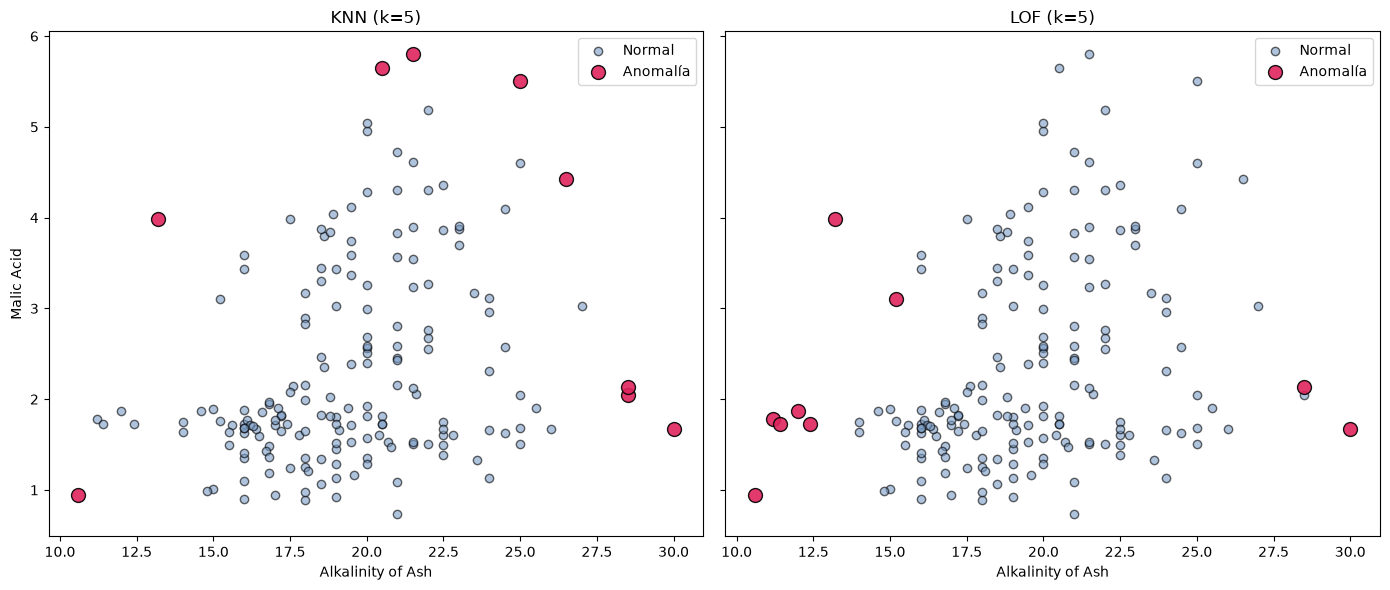

In [119]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Caja 1: KNN
normales_knn = df[df['knn_pred'] == 0]
anomalias_knn = df[df['knn_pred'] == 1]
axes[0].scatter(normales_knn['alcalinity_of_ash'], normales_knn['malic_acid'],
                alpha=0.6, edgecolor='k', color='#7A9CC6', label='Normal')
axes[0].scatter(anomalias_knn['alcalinity_of_ash'], anomalias_knn['malic_acid'],
                alpha=0.9, edgecolor='k', color='#E0245E', s=100, label='Anomalía')
axes[0].set_xlabel('Alkalinity of Ash')
axes[0].set_ylabel('Malic Acid')
axes[0].set_title('KNN (k=5)')
axes[0].legend()

# Caja 2: LOF
normales_lof = df[df['lof_pred'] == 1]     # recordar: sklearn crudo, 1=normal
anomalias_lof = df[df['lof_pred'] == -1]   # recordar: sklearn crudo, -1=anomalía
axes[1].scatter(normales_lof['alcalinity_of_ash'], normales_lof['malic_acid'],
                alpha=0.6, edgecolor='k', color='#7A9CC6', label='Normal')
axes[1].scatter(anomalias_lof['alcalinity_of_ash'], anomalias_lof['malic_acid'],
                alpha=0.9, edgecolor='k', color='#E0245E', s=100, label='Anomalía')
axes[1].set_xlabel('Alkalinity of Ash')
axes[1].set_title('LOF (k=5)')
axes[1].legend()

plt.tight_layout()
plt.show()